In [2]:
from pathlib import Path
import os
import shutil

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.stats import sigma_clipped_stats



In [4]:

base_path = "/home/otteleno/fall"
source_root = f"{base_path}/fall_data/"
dest_root = f"{base_path}/fall_images/unscrambled/"

for dirpath, dirnames, filenames in os.walk(source_root):
    folder_name = os.path.basename(dirpath)
    
    if folder_name.endswith("mf"):  # or startswith, or both
        for filename in filenames:
            src_file = os.path.join(dirpath, filename)
            dst_file = os.path.join(dest_root, filename)
            shutil.copy2(src_file, dst_file)


NameError: name 'norm' is not defined

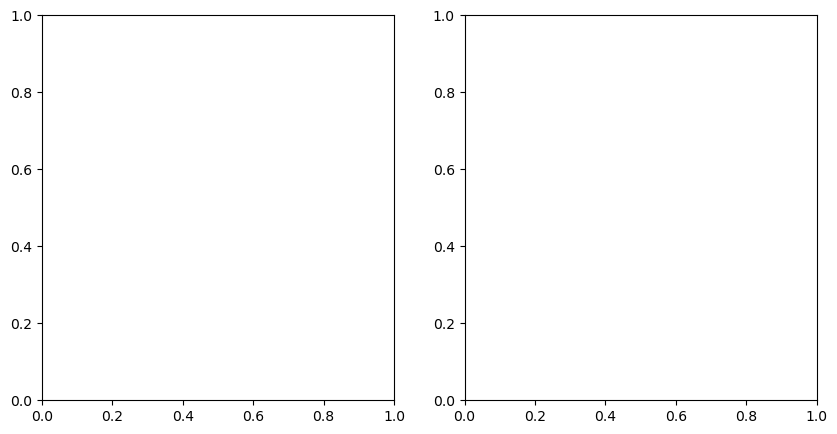

In [16]:
CMAP = "gray_r"                       
MY_EXTENT = [-60, 60, -60, 60]       
KERNEL_STDDEV = 0.7                  
CLIP_SIGMA = 2                       
CLIP_MAXITERS = 4                    
CONTOUR_LEVELS = [4, 5, 7, 10, 20, 50, 100, 150]  
CONTOUR_COLOR = "white"
CONTOUR_LINEWIDTH = 1.0

def create_png(fits_file):
    hdul = fits.open(fits_file)
    data = hdul[0].data 

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    kernel = Gaussian2DKernel(x_stddev=KERNEL_STDDEV)
    smoothmap = convolve(data, kernel)

    mean, median, sigma = sigma_clipped_stats(smoothmap, sigma=CLIP_SIGMA, maxiters=CLIP_MAXITERS)
    sig_array = (smoothmap - median) / sigma

    # Panel 1: Raw Data
    ax[0].imshow(data, extent=MY_EXTENT, cmap=CMAP, norm=norm, origin="lower", aspect='equal')
    ax[0].axis('off')
    
    # Panel 2: Contours
    ax[1].imshow(data, extent=MY_EXTENT, cmap=CMAP, norm=norm, origin="lower", aspect='equal')     
    ax[1].contour(sig_array, extent=MY_EXTENT, colors=CONTOUR_COLOR, 
                  levels=CONTOUR_LEVELS, linewidths=CONTOUR_LINEWIDTH, origin="lower")
    ax[1].axis('off')

    save_location = f"{base_path}/fall_images/scrambled/1.png"
    fig.savefig(save_location, dpi=300, bbox_inches='tight', pad_inches=0)
    
    plt.show()
    plt.close(fig) 
    return
    
test_file = f"{base_path}/fall_images/unscrambled/rogue_5_26p5_2000_mf_96.6_251.0.fits"
create_png(test_file)

